In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

df_clean = pd.read_csv(r"C:\Users\Bhadmus\Documents\Codeveda Project\Online_Sales_Analytics\Task4\New_cleaned_online_retail.csv")

# 1. Ensure InvoiceDate is a datetime object
df_clean['Invoicedate'] = pd.to_datetime(df_clean['Invoicedate'])

# 2. Group by Day to see daily revenue trends
daily_revenue = df_clean.set_index('Invoicedate')['Revenue'].resample('D').sum()


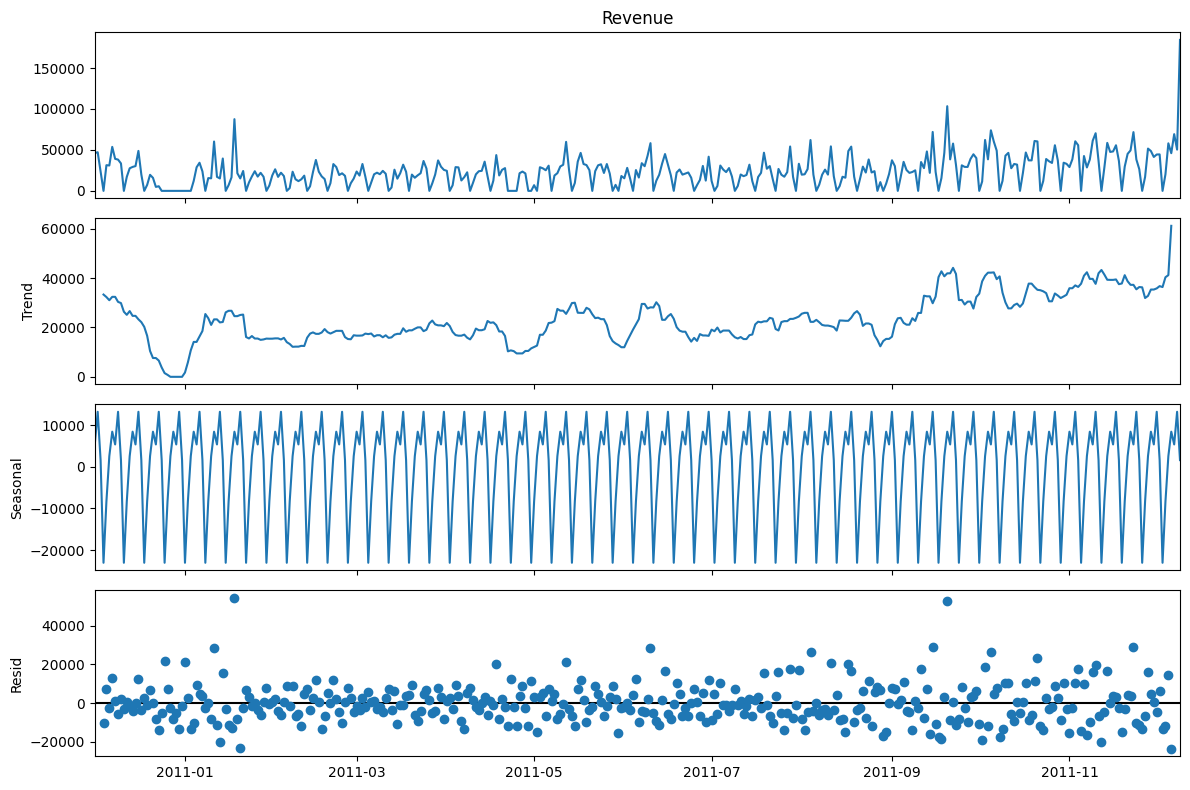

In [9]:
# Perform decomposition (assuming a weekly cycle of 7 days)
decomposition = seasonal_decompose(daily_revenue, model='additive', period=7)

# Plot the results
plt.rcParams['figure.figsize'] = (12, 8)
decomposition.plot()
plt.show()

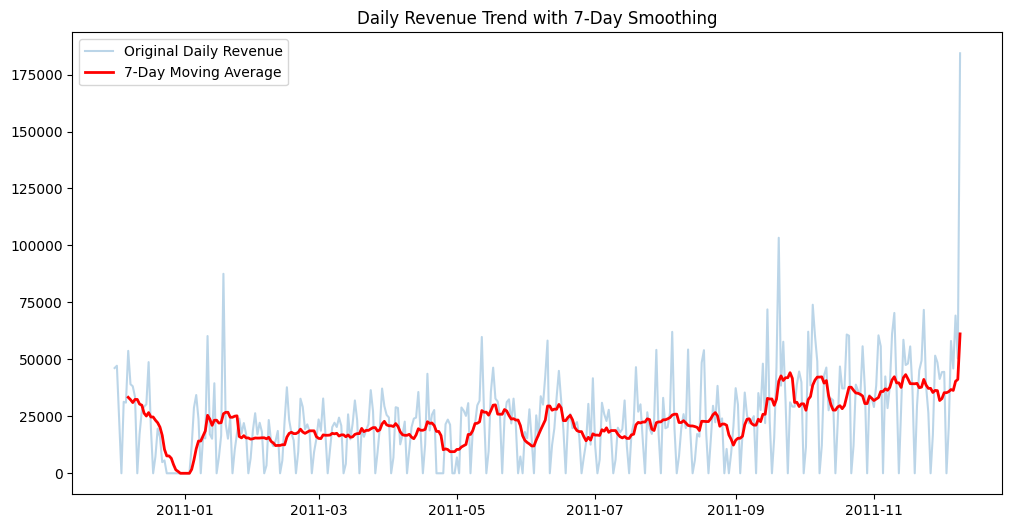

In [10]:
# 7-day moving average to smooth out daily fluctuations
daily_revenue_smooth = daily_revenue.rolling(window=7).mean()

plt.figure(figsize=(12,6))
plt.plot(daily_revenue, label='Original Daily Revenue', alpha=0.3)
plt.plot(daily_revenue_smooth, label='7-Day Moving Average', color='red', linewidth=2)
plt.title('Daily Revenue Trend with 7-Day Smoothing')
plt.legend()
plt.show()

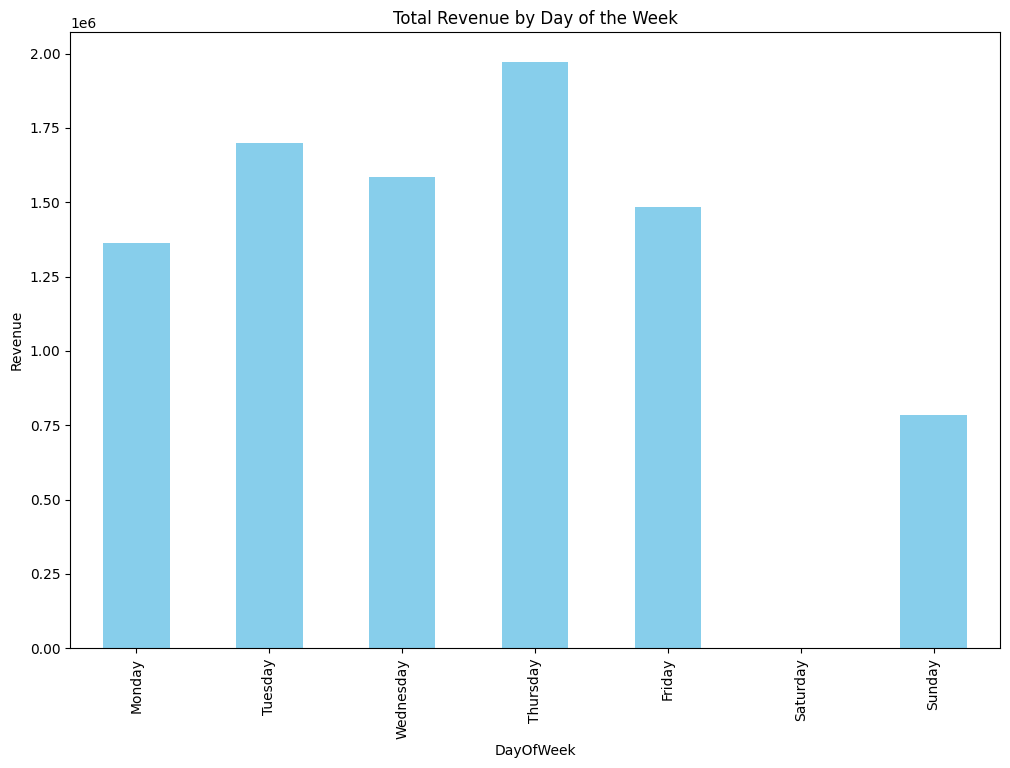

In [12]:
# Create a Day of Week column
df_clean['DayOfWeek'] = df_clean['Invoicedate'].dt.day_name()

# Sum revenue by day
day_growth = df_clean.groupby('DayOfWeek')['Revenue'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

# Plot it
day_growth.plot(kind='bar', color='skyblue')
plt.title('Total Revenue by Day of the Week')
plt.ylabel('Revenue')
plt.show()